In [1]:
import numpy as np
from numpy.fft import ifft2, fftshift
import matplotlib.pyplot as plt
from scipy.linalg import expm, inv
from scipy.optimize import root, minimize_scalar, minimize
import time

kappa_aa = 0 
kappa_bb = 0
kappa_ab = 0
kappa_ba = 0
Gamma_aa = 1
Gamma_bb = 1
Gamma_ab = 0
Gamma_ba = 0
A_fixedpoint = 0.35
B_fixedpoint = 0.35
D_A = 0.1
D_B = 0.1
D_v = 0
Nx = 256
Ny = 256
Lx = 256
Ly = 256
h = Lx/Nx

params = {
    'D_A': D_A, 'D_B': D_B, 'D_v': D_v,
    'beta': 1.0/D_A, 'h': h,
    'kappa': [[kappa_aa, kappa_ab],[kappa_ba, kappa_bb]],
    'Gamma': [[Gamma_aa, Gamma_ab],[Gamma_ba, Gamma_bb]],
    'a0': A_fixedpoint, 'b0': B_fixedpoint
}

grid = {'Nx': Nx, 'Ny': Ny, 'Lx': Lx, 'Ly': Ly}
times = np.linspace(0.0, 5.0, 51)
# ---------- Functions (linearized model) ----------
def build_L_matrices(params):
    Da, Db, Dv = params['D_A'], params['D_B'], params['D_v']
    beta = params['beta']
    a0, b0 = params['a0'], params['b0']
    s0 = 1.0 - a0 - b0
    kap = np.array(params['kappa'])
    Gam = np.array(params['Gamma'])
    A0 = np.zeros((2,2)); A1 = np.zeros((2,2))
    pref = lambda D, rho: D * beta * s0 * rho

    A0[0,0] = Da*(s0 + a0) + Dv*b0
    A0[1,1] = Db*(s0 + b0) + Dv*a0
    A0[0,1] = Da*a0 - Dv*a0
    A0[1,0] = Db*b0 - Dv*b0

    A0[0,0] -= pref(Da, a0)*kap[0,0]
    A0[0,1] -= pref(Da, a0)*kap[0,1]
    A0[1,0] -= pref(Db, b0)*kap[1,0]
    A0[1,1] -= pref(Db, b0)*kap[1,1]

    A1[0,0] = - pref(Da, a0) * Gam[0,0]
    A1[0,1] = - pref(Da, a0) * Gam[0,1]
    A1[1,0] = - pref(Db, b0) * Gam[1,0]
    A1[1,1] = - pref(Db, b0) * Gam[1,1]

    return A0, A1

def frequency(k, J, Q):
    W = k**2*(J.trace() - k**2* Q.trace())
    adjJ = np.array([[J[1,1],-J[0,1]],[-J[1,0],J[0,0]]])
    Z = k**4*(np.linalg.det(J)-k**2*np.trace(adjJ @ Q) + k**4*np.linalg.det(Q))
    D = 4*Z-W**2
    sqrtD = np.where(D>=0, np.sqrt(D), 1j*np.sqrt(np.abs(D)))
    omega_plus = 1/2*(-1j*W + sqrtD)
    omega_min = 1/2*(-1j*W - sqrtD)
    return omega_plus, omega_min

def rates(k, J, Q):
    om_plus, om_min = frequency(k, J, Q)
    return np.minimum(- om_plus.imag, - om_min.imag)


In [2]:

def optimize_rate(J, Q, k_bounds=(0.1, 5.0)):
    # Minimize the negative of the rate over k
    result = minimize_scalar(rates, bounds=k_bounds, args=(J, Q), method='bounded')
    
    # If successful, return the optimal value of k and the maximum rate
    if result.success:
        optimal_k = result.x
        max_rate = -result.fun  # Since we minimized the negative rate
        return optimal_k, max_rate
    else:
        raise ValueError("Optimization failed.")

In [3]:

# This function will calculate the max rate for given theta and D_v
def objective_Dv(D_v, params):

    # Update the params dictionary with new values for theta and D_v
    params['D_v'] = D_v

    # Calculate the L matrices
    A0, A1 = build_L_matrices(params)

    # Optimize for k to get the max_rate
    result = root(rates, 10, (A0,A1))
    
    # Return the absolute value of the max_rate (we want it close to zero)
    if result.success:
        root_k = result.x[0]
        return root_k**2
    else:
        return D_v

# Now we set up the optimization over theta and D_v
def find_critical_Dv(params, initial_guess=1):
    # Initial guess for theta and D_v
    D_v_initial = initial_guess

    # Minimize the absolute value of the max_rate (objective function)
    result = minimize_scalar(
        objective_Dv,
        initial_guess,
        args=(params),
        bounds=(1e-6, 10),  # Bounds for D_v
        method='bounded'  # Optimization method
    )

    # Check if the optimization was successful
    if result.success:
        optimal_D_v = result.x
        return optimal_D_v, result.fun  # result.fun is the value of the objective function (should be close to 0)
    else:
        raise ValueError("Optimization failed.")



In [4]:
theta = 1/2
kappa_aa = 1 - theta
kappa_bb = 1 - theta
kappa_ab = - theta
kappa_ba = - theta
Gamma_aa = 1
Gamma_bb = 1
Gamma_ab = 0
Gamma_ba = 0
A_fixedpoint = 0.35
B_fixedpoint = 0.35
D_A = 0.1
D_B = 0.1
D_v = 0.1
Nx = 256
Ny = 256
Lx = 256
Ly = 256
h = Lx/Nx

params = {
    'D_A': D_A, 'D_B': D_B, 'D_v': D_v,
    'beta': 1.0/D_A, 'h': h,
    'kappa': [[kappa_aa, kappa_ab],[kappa_ba, kappa_bb]],
    'Gamma': [[Gamma_aa, Gamma_ab],[Gamma_ba, Gamma_bb]],
    'a0': A_fixedpoint, 'b0': B_fixedpoint
}

crit_Dv, rootksqr = find_critical_Dv(params)

print(crit_Dv)

/tmp/ipykernel_3186201/2157657910.py:70: RuntimeWarning: invalid value encountered in sqrt
  sqrtD = np.where(D>=0, np.sqrt(D), 1j*np.sqrt(np.abs(D)))


0.1071412210752047


{'D_A': 0.1, 'D_B': 0.1, 'D_v': 1, 'beta': 10.0, 'h': 1.0, 'kappa': [[0.99, -0.01], [-0.01, 0.99]], 'Gamma': [[1, 0], [0, 1]], 'a0': 0.35, 'b0': 0.35}


/tmp/ipykernel_3186201/2157657910.py:70: RuntimeWarning: invalid value encountered in sqrt
  sqrtD = np.where(D>=0, np.sqrt(D), 1j*np.sqrt(np.abs(D)))


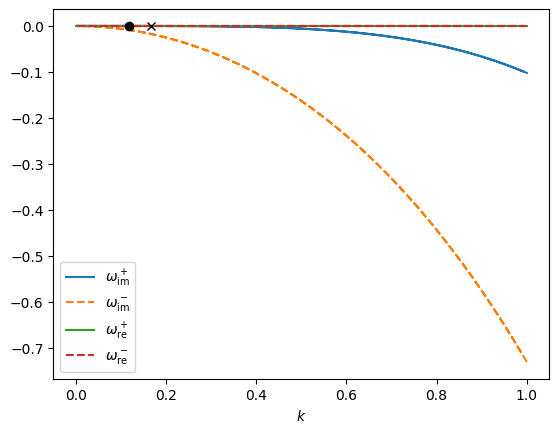

In [5]:
params['D_v'] = 1
theta = 0.01
kappa_aa = 1 - theta
kappa_bb = 1 - theta
kappa_ab = - theta
kappa_ba = - theta
params['kappa'] = [[kappa_aa, kappa_ab],[kappa_ba, kappa_bb]]
params['a0'] = 0.35
params['b0'] = 0.35
k = np.fft.fftfreq(Nx, d=0.5)
k = np.fft.fftshift(k)
J, Q = build_L_matrices(params)
print(params)
om_plus, om_min  = frequency(k, J, Q)
k_star, r_star = optimize_rate(J, Q, k_bounds=(1e-6, np.max(k)))
freq_root = root(rates, 20, (J,Q))
om_zero = freq_root.x
plt.plot(np.abs(k), om_plus.imag, label = r"$\omega^+_{\rm im}$")
plt.plot(np.abs(k), om_min.imag, "--", label = r"$\omega^-_{\rm im}$")
plt.plot(np.abs(k), om_plus.real, label = r"$\omega^+_{\rm re}$")
plt.plot(np.abs(k), om_min.real, "--",  label = r"$\omega^-_{\rm re}$")
plt.plot(k_star, r_star, "ko" )
plt.plot(om_zero,0, "kx")
plt.legend()
plt.xlabel(r"$k$")
plt.show()


In [154]:
freq_root

 message: The number of calls to function has reached maxfev = 400.
 success: False
  status: 2
     fun: [ 3.791e-161]
       x: [ 1.088e-79]
  method: hybr
    nfev: 402
    fjac: [[-1.000e+00]]
       r: [-1.475e-81]
     qtf: [-9.924e-161]

In [155]:
freq_root = root(rates, 20, (J,Q))

/tmp/ipykernel_2299597/2157657910.py:70: RuntimeWarning: invalid value encountered in sqrt
  sqrtD = np.where(D>=0, np.sqrt(D), 1j*np.sqrt(np.abs(D)))


In [156]:
freq_root.x

array([1.08839026e-79])

/tmp/ipykernel_2299597/2157657910.py:70: RuntimeWarning: invalid value encountered in sqrt
  sqrtD = np.where(D>=0, np.sqrt(D), 1j*np.sqrt(np.abs(D)))


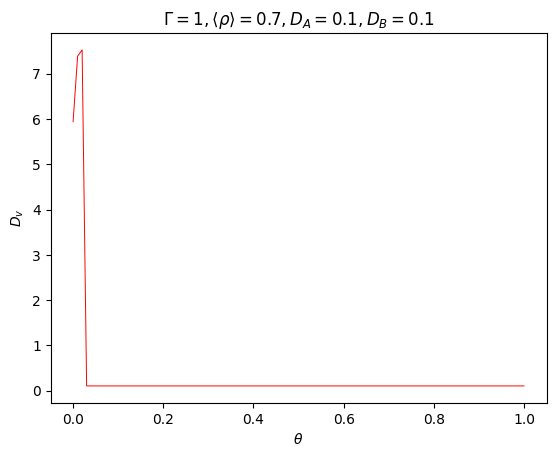

In [158]:
theta_space = np.linspace(0,1,101)
critical_DVs = np.zeros(101)
params["D_v"] = 0
params['a0'] = 0.35
params['b0'] = 0.35

for i, theta in enumerate(theta_space):
    kappa_aa = 1 - theta
    kappa_bb = 1 - theta
    kappa_ab = - theta
    kappa_ba = - theta
    params['kappa'] = [[kappa_aa, kappa_ab],[kappa_ba, kappa_bb]]
    crit_Dv, rootksqr = find_critical_Dv(params)
    critical_DVs[i] = crit_Dv
    params["D_v"] = crit_Dv

title = rf"$\Gamma = 1, \langle \rho \rangle = {params['a0']+params['b0']}, D_A = {D_A}, D_B = {D_B} $"
plt.plot(theta_space, critical_DVs, 'r', lw= 0.7)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$D_v$")
plt.title(title)
# plt.ylim([0.,1])
plt.show()

/tmp/ipykernel_2299597/2157657910.py:70: RuntimeWarning: invalid value encountered in sqrt
  sqrtD = np.where(D>=0, np.sqrt(D), 1j*np.sqrt(np.abs(D)))


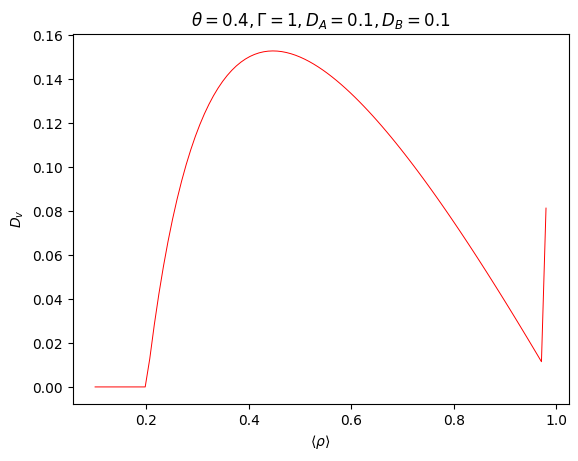

In [160]:
rho0_space = np.linspace(0.1,0.98,100)
critical_DVs = np.zeros(100)
theta = 2/5
kappa_aa = 1 - theta
kappa_bb = 1 - theta
kappa_ab = - theta
kappa_ba = - theta
params['kappa'] = [[kappa_aa, kappa_ab],[kappa_ba, kappa_bb]]
params["D_v"] = 0
for i, rho0 in enumerate(rho0_space):
    params['a0'] = rho0/2
    params['b0'] = rho0/2
    crit_Dv, rootksqr = find_critical_Dv(params)
    critical_DVs[i] = crit_Dv
    params["D_v"] = crit_Dv

title = rf"$\theta = {theta}, \Gamma = 1, D_A = {D_A}, D_B = {D_B} $"
plt.plot(rho0_space, critical_DVs, 'r', lw= 0.7)
plt.xlabel(r"$\langle \rho \rangle$")
plt.ylabel(r"$D_v$")
plt.title(title)
# plt.ylim([0.,1])
plt.show()